In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def y_analytical(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

In [12]:
def euler_forward(f, y0, t0, t_end, h):
    n_steps = int((t_end - t0) / h)
    t = np.linspace(t0, t_end, n_steps + 1)
    y = np.zeros_like(t)
    y[0] = y0

    for i in range(n_steps):
        y[i+1] = y[i] + h * f(t[i], y[i])

    return t, y

In [14]:
h_values = [0.1, 0.01, 0.001] #0.00001, 0.0000001]  # Last two weren't running so I commented them out sorry
t0 = 0
t_end = 30
y0 = 0

Computing Euler Forward for h = 0.1 ...
Computing Euler Forward for h = 0.01 ...
Computing Euler Forward for h = 0.001 ...


<ipython-input-11-a370843d6589>:2: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-12-545db2d9f59b>:8: RuntimeWarning: invalid value encountered in double_scalars
  y[i+1] = y[i] + h * f(t[i], y[i])


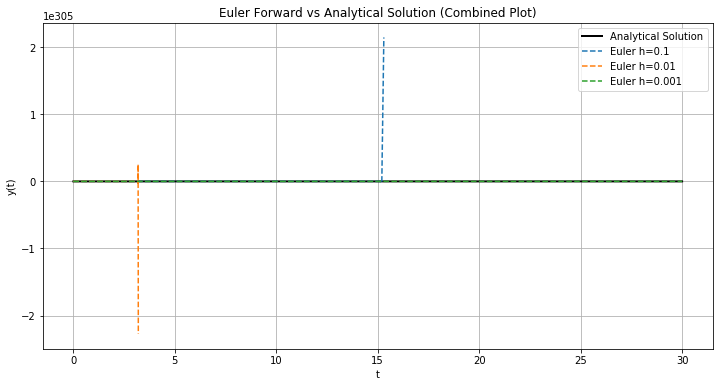

In [15]:
plt.figure(figsize=(12,6))

# Plot analytical solution
t_fine = np.linspace(t0, t_end, 5000)
plt.plot(t_fine, y_analytical(t_fine), 'k', linewidth=2, label='Analytical Solution')

# Plot Euler solutions for each h
for h in h_values:
    print(f"Computing Euler Forward for h = {h} ...")
    t_num, y_num = euler_forward(f, y0, t0, t_end, h)
    plt.plot(t_num, y_num, '--', label=f'Euler h={h}')

plt.title("Euler Forward vs Analytical Solution (Combined Plot)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.legend()
plt.show()